# Collect all the results for uRegister and uUnwrap

In [1]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
from tqdm import tqdm
from collections import defaultdict
from skimage.draw import polygon
from skimage import measure
import pickle
from concurrent.futures import ProcessPoolExecutor, as_completed
import skimage.morphology as skmorph
from skimage.measure import regionprops, find_contours
from skimage.draw import polygon
from joblib import Parallel, delayed

import sys
sys.path.append("../unwrap2D/")
from unwrap2D import uv_to_yx_pts2D
sys.path.append("../utils/")
from run_stack import unwrap2D_all_TF, window_all_TF, calculate_window_intensity, calculate_all_windowd, \
                        plot_window_d, plot_intensity, create_contour_evolve


# all u-Register and u-Unwrap results have been pre-run and saved

def load_cell_windows_layers(mat_path):
    md = sio.loadmat(mat_path)
    return md['windows'][0]


def load_avg_from_mat(path):
    md = sio.loadmat(path)
    samples = md['samples']
    avg = samples['avg'][0][0]
    return np.asarray(avg).squeeze().astype(np.float32)
def compute_area_and_eccentricity_from_windows(windows_layers,shape, window_num):

    eccentricities_lw = defaultdict(list)
    area_lw = defaultdict(list)
    for i, layers in enumerate(windows_layers):
        theta_idx = i % window_num 
        layers = layers[0] 
        for layer_idx, layer_polys in enumerate(layers):
            lines = layer_polys[0]
            # col = color_by_layer(layer_idx)
            all_x = []
            all_y = []
            for line in lines:
                line = np.asarray(line)
        
                #window_xy_area_portion_img = np.zeros(img_size, dtype=np.uint8)
                if line.ndim == 2 and line.shape[0] == 2 and line.shape[1] > 1:
                    y = line[0].ravel()
                    x = line[1].ravel()
                    all_y.extend(y)
                    all_x.extend(x)

            # ax.plot(all_y, all_x, linewidth=0.6)
            
                
                # rr, cc = polygon(xy[:, 0], xy[:, 1], shape=img_size)
            #window_xy_area_portion_img[all_y, all_x] = 1
            if len(all_y) == 0:
                eccentricities_lw[layer_idx].append(np.nan)
                area_lw[layer_idx].append(np.nan)
            else:
                rr, cc = polygon(all_y, all_x, shape=shape)
                mask = np.zeros(shape, dtype=np.uint8)
                mask[rr, cc] = 1
                props = measure.regionprops(mask)

            if len(props) == 0:
                eccentricities_lw[layer_idx].append(np.nan)
                area_lw[layer_idx].append(np.nan)
            else:
                eccentricities_lw[layer_idx].append(props[0].eccentricity)
                area_lw[layer_idx].append(props[0].area)


        with open(os.path.join(folder, 'layerwise_eccentricity.pkl'), 'wb') as f:
            pickle.dump(eccentricities_lw, f)

        coef_list = []
        for layer, ecc in eccentricities_lw.items():
            ecc = np.array(ecc)

            if len(ecc) == 0 or np.all(np.isnan(ecc)) or np.nanmean(ecc) == 0:
                std_over_mean = np.nan
            else:
                std_over_mean = np.nanstd(ecc) / np.nanmean(ecc)
            coef_list.append(std_over_mean)

        area_list = []
        for layer, area in area_lw.items():
            area_list.append(area)

        with open(os.path.join(folder, "layerwise_eccentricity_coef.pkl"), "wb") as f:
            pickle.dump(coef_list, f)

        with open(os.path.join(folder, "layerwise_area.pkl"), "wb") as f:
            pickle.dump(area_list, f)

    return coef_list, area_list
    
def compute_completeness_from_avg(avg_img, max_layers=12):
    avg_img = avg_img[:, :max_layers]
    mask = ~np.isnan(avg_img)
    return np.mean(mask, axis=0)


In [2]:

def load_cell_windows_layers(mat_path):
    md = sio.loadmat(mat_path)
    return md['windows'][0]


def load_avg_from_mat(path):
    md = sio.loadmat(path)
    samples = md['samples']
    avg = samples['avg'][0][0]
    return np.asarray(avg).squeeze().astype(np.float32)

def compute_area_and_eccentricity_from_windows(
    windows_layers,
    img_shape,
    max_layers=12
):
   

    ecc_by_layer = defaultdict(list)
    area_by_layer = defaultdict(list)

    for theta_idx, layers in enumerate(windows_layers):
        layers = layers[0]  # matlab cell unwrap

        for layer_idx, layer_polys in enumerate(layers):
            all_x, all_y = [], []

            for line in layer_polys[0]:
                line = np.asarray(line)
                if line.ndim == 2 and line.shape[0] == 2 and line.shape[1] > 1:
                    all_y.extend(line[0])
                    all_x.extend(line[1])

            if len(all_x) == 0:
                ecc_by_layer[layer_idx].append(np.nan)
                area_by_layer[layer_idx].append(np.nan)
                continue

            rr, cc = polygon(all_y, all_x, shape=img_shape)
            mask = np.zeros(img_shape, dtype=np.uint8)
            mask[rr, cc] = 1
            props = measure.regionprops(mask)

            if len(props) == 0:
                ecc_by_layer[layer_idx].append(np.nan)
                area_by_layer[layer_idx].append(np.nan)
            else:
                ecc_by_layer[layer_idx].append(props[0].eccentricity)
                area_by_layer[layer_idx].append(props[0].area)

  
    coef_list = []
    area_list = []

    for k in range(max_layers):
        ecc = np.asarray(ecc_by_layer.get(k, []))
        if ecc.size == 0 or np.all(np.isnan(ecc)) or np.nanmean(ecc) == 0:
            coef_list.append(np.nan)
        else:
            coef_list.append(np.nanstd(ecc) / np.nanmean(ecc))

        area_list.append(area_by_layer.get(k, []))

    return coef_list, area_list

def compute_completeness_from_avg(avg_img, max_layers=12):
    avg_img = avg_img[:, :max_layers]
    return np.mean(~np.isnan(avg_img), axis=0)

def process_one_file(file_path, uregister_root, img_shape, max_layers=12):

    folder_suffix = (
        file_path.split("/")[-2]
        + "_"
        + file_path.split("/")[-1].replace(".png", "")
    )
    cell_folder = os.path.join(uregister_root, folder_suffix)

    window_mat = os.path.join(
        cell_folder,
        "uRegisterPackage/windows/windows_frame__frame_1.mat"
    )
    avg_mat = os.path.join(
        cell_folder,
        "uRegisterPackage/window_sampling/Raw images - channel 1.mat"
    )


    if not (os.path.exists(window_mat) and os.path.exists(avg_mat)):
        return None

    windows_layers = load_cell_windows_layers(window_mat)
    avg_img = load_avg_from_mat(avg_mat)

    coef_list, area_list = compute_area_and_eccentricity_from_windows(
        windows_layers,
        img_shape,
        max_layers=max_layers
    )

    completeness = compute_completeness_from_avg(avg_img, max_layers)

    return {
        "cell_id": folder_suffix,
        "coef": coef_list,          
        "area": area_list,           
        "completeness": completeness
    }


SPOT_file_csv_test = pd.read_csv(
    "/work/bioinformatics/s440708/unwrap2D_paper/temporary_save_files/SPOT_test_file_list.csv"
)

uregister_folder_test = (
    "/work/bioinformatics/s440708/unwrap2D_paper/temporary_save_files/"
    "figure1_cellpose_uregister_test"
)

img_size = (512, 512)


test_results = Parallel(n_jobs=-1, backend="loky", verbose=1)(
    delayed(process_one_file)(files, uregister_folder_test, img_size)
    for files in SPOT_file_csv_test['values']
)


SPOT_file_csv_train = pd.read_csv(
    "/work/bioinformatics/s440708/unwrap2D_paper/temporary_save_files/SPOT_train_file_list.csv"
)

uregister_folder_train = (
    "/work/bioinformatics/s440708/unwrap2D_paper/temporary_save_files/"
    "figure1_cellpose_uregister_train"
)

img_size = (512, 512)


train_results = Parallel(n_jobs=-1, backend="loky", verbose=1)(
    delayed(process_one_file)(files, uregister_folder_train, img_size)
    for files in SPOT_file_csv_train['values']
)



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done 354 tasks      | elapsed:   20.6s
[Parallel(n_jobs=-1)]: Done 704 tasks      | elapsed:   43.7s
[Parallel(n_jobs=-1)]: Done 1154 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 1704 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 2354 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 3104 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done 3954 tasks      | elapsed:  4.3min
[Parallel(n_jobs=-1)]: Done 4904 tasks      | elapsed:  5.4min
[Parallel(n_jobs=-1)]: Done 5954 tasks      | elapsed:  6.6min
[Parallel(n_jobs=-1)]: Done 6117 out of 6117 | elapsed:  6.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 354 tasks      | elapsed:    7.7s
[Parallel(n_jobs=-1)]:

In [3]:
# distribute different part of the results
ecc_results = [r['coef'] for r in test_results] + [r['coef'] for r in train_results]
area_results = [r['area'] for r in test_results] + [r['area'] for r in train_results]
completeness_results = [r['completeness'] for r in test_results] + [r['completeness'] for r in train_results]

In [4]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import skimage.morphology as skmorph
from skimage.measure import regionprops, find_contours
from skimage.draw import polygon

# collect and calculate all the unwrap results
def process_uunwrap(
    file_path,
    uunwrap_root,
    img_size,
    R_NUM,
    THETA_NUM,
    raster_size=256,
    border_pad=32,
    layer_col="layer_index",
    completeness_col="completeness",
):
  
    cell_id = (
        file_path.split("/")[-2]
        + "_"
        + file_path.split("/")[-1].replace(".png", "")
    )
    folder = os.path.join(uunwrap_root, cell_id)

    out = {
        "cell_id": cell_id,
        "completeness": {},
        "eccentricity_coef": None,
        "area_lw": None,   
    }


    comp_csv = os.path.join(folder, "completeness.csv")
    df = pd.read_csv(comp_csv)

    for _, row in df[[layer_col, completeness_col]].iterrows():
        layer = int(row[layer_col])
        out["completeness"][layer] = float(row[completeness_col])

    if os.path.exists(os.path.join(folder, "layerwise_eccentricity_coef.npy")):
        eccentricities_lw = np.load(os.path.join(folder, "layerwise_eccentricity_coef.npy"))
        areas_lw = np.load(os.path.join(folder, "layerwise_area.npy"))  
        out["eccentricity_coef"] = eccentricities_lw
        out["area_lw"] = areas_lw
        return out

    
    with open(os.path.join(folder, "unwrap_img_stack.pkl"), "rb") as f:
        unwrap_img_stack = pickle.load(f)

    with open(os.path.join(folder, "unwrap_params_stack.pkl"), "rb") as f:
        unwrap_params_stack = pickle.load(f)

    with open(os.path.join(folder, "unwrap_mask_stack.pkl"), "rb") as f:
        unwrap_mask_stack = pickle.load(f)

    unwrap_valid_mask = unwrap_mask_stack[0]
    eroded_valid_mask = skmorph.binary_erosion(
        unwrap_valid_mask, skmorph.disk(1)
    )

    window_stack = window_all_TF(
        [unwrap_img_stack[0]],
        [unwrap_params_stack[0]],
    )

    calculate_window_intensity(
        window_stack,
        r_num=R_NUM,
        theta_num=THETA_NUM,
        layer_n=1
    )

    all_masks = window_stack[0].segment_masks

    eccentricities = []
    areas = []   

    for jj, mask in enumerate(all_masks):

        if jj < THETA_NUM:
            mask = mask & eroded_valid_mask

        contours = find_contours(mask)
        if len(contours) == 0:
            eccentricities.append(np.nan)
            areas.append(np.nan)
            continue

        contour = max(contours, key=len)
        xy = uv_to_yx_pts2D(contour, unwrap_params_stack[0])

        poly_mask = np.zeros(img_size, dtype=np.uint8)
        rr, cc = polygon(xy[:, 0], xy[:, 1], shape=img_size)
        poly_mask[rr, cc] = 1

        props = regionprops(poly_mask)
        if len(props) > 0:
            eccentricities.append(props[0].eccentricity)
            areas.append(props[0].area)   
        else:
            eccentricities.append(np.nan)
            areas.append(np.nan)

    eccentricities = np.asarray(eccentricities)
    areas = np.asarray(areas)

    eccentricities_lw = eccentricities.reshape(-1, THETA_NUM)
    areas_lw = areas.reshape(-1, THETA_NUM)

    np.save(os.path.join(folder, "layerwise_eccentricity.npy"), eccentricities_lw)
    np.save(os.path.join(folder, "layerwise_eccentricity_coef.npy"),
            np.nanstd(eccentricities_lw, axis=1) /
            (np.nanmean(eccentricities_lw, axis=1) + 1e-6))

    np.save(os.path.join(folder, "layerwise_area.npy"), areas_lw)  

    out["eccentricity_coef"] = (
        np.nanstd(eccentricities_lw, axis=1) /
        (np.nanmean(eccentricities_lw, axis=1) + 1e-6)
    )
    out["area_lw"] = areas_lw  

    return out

def run_uunwrap_all_metrics_parallel(
    csv_path,
    uunwrap_root,
    img_size,
    R_NUM,
    THETA_NUM,
    max_workers=8
):
    df = pd.read_csv(csv_path)
    results = []
    failed = []

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(
                process_uunwrap,
                file_path=f,
                uunwrap_root=uunwrap_root,
                img_size=img_size,
                R_NUM=R_NUM,
                THETA_NUM=THETA_NUM
            ): f
            for f in df["values"]
        }

        for future in tqdm(as_completed(futures), total=len(futures)):
            file = futures[future]
            try:
                results.append(future.result())
            except Exception as e:
                print(f"[Fail] {file}: {e}")
                failed.append(file)

    return results, failed

R_NUM=12
THETA_NUM=60
test_unwrap_results, failed_files = run_uunwrap_all_metrics_parallel(
    csv_path="/work/bioinformatics/s440708/unwrap2D_paper/temporary_save_files/SPOT_test_file_list.csv",
    uunwrap_root="/work/bioinformatics/s440708/unwrap2D_paper/temporary_save_files/figure1_cellpose_test_unwrap2D_256",
    img_size=(512, 512),
    R_NUM=R_NUM,
    THETA_NUM=THETA_NUM,
    max_workers=48
)

R_NUM=12
THETA_NUM=60
train_unwrap_results, failed_files = run_uunwrap_all_metrics_parallel(
    csv_path="/work/bioinformatics/s440708/unwrap2D_paper/temporary_save_files/SPOT_train_file_list.csv",
    uunwrap_root="/work/bioinformatics/s440708/unwrap2D_paper/temporary_save_files/figure1_cellpose_unwrap2D",
    img_size=(512, 512),
    R_NUM=R_NUM,
    THETA_NUM=THETA_NUM,
    max_workers=48
)


100%|██████████| 51584/51584 [00:23<00:00, 2192.77it/s]


# Plot Eccentricity

(57701, 12)


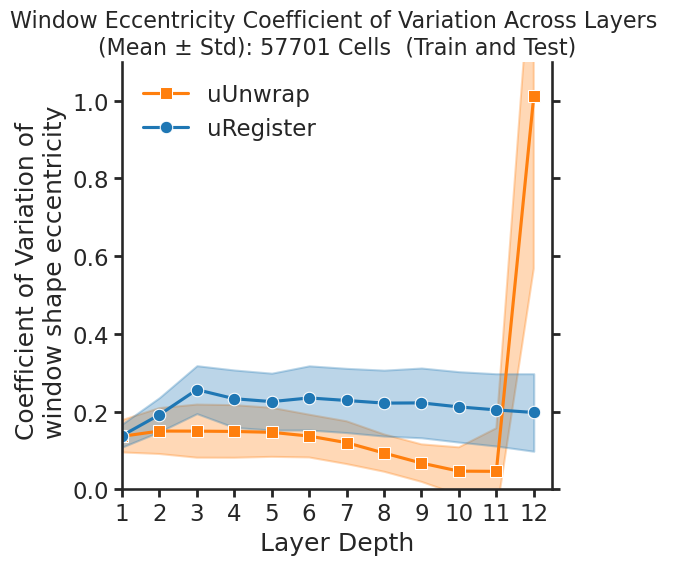

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# plot coef 

fixed_all_coef = [
    np.pad(lst[:12], (0, max(0, 12 - len(lst))), constant_values=np.nan)
    for lst in ecc_results
]
all_coef_uregister = np.array(fixed_all_coef)
all_coef_unwrap = [results['eccentricity_coef'] for results in train_unwrap_results] + [results['eccentricity_coef'] for results in test_unwrap_results]
print(all_coef_uregister.shape)

coef_mean_uUnwrap = np.nanmean(all_coef_unwrap, axis=0)
coef_std_uUnwrap = np.nanstd(all_coef_unwrap, axis=0)

coef_mean_uRegister = np.nanmean(all_coef_uregister, axis=0)
coef_std_uRegister = np.nanstd(all_coef_uregister, axis=0)
x = np.arange(1, 13)


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans"],
    "axes.linewidth": 2,
})

sns.set(style="white", context="talk")

plt.figure(figsize=(6,6))




sns.lineplot(x=x, y=coef_mean_uUnwrap, marker='s', label='uUnwrap', color='#ff7f0e')
plt.fill_between(x, coef_mean_uUnwrap - coef_std_uUnwrap, coef_mean_uUnwrap + coef_std_uUnwrap, 
                 color='#ff7f0e', alpha=0.3)

sns.lineplot(x=x, y=coef_mean_uRegister, marker='o', label='uRegister', color='#1f77b4')
plt.fill_between(x, coef_mean_uRegister - coef_std_uRegister, coef_mean_uRegister + coef_std_uRegister, 
                 color='#1f77b4', alpha=0.3)


plt.xlabel('Layer Depth')
plt.ylabel('Coefficient of Variation of \n window shape eccentricity')
plt.title('Window Eccentricity Coefficient of Variation Across Layers \n(Mean ± Std): 57701 Cells  (Train and Test)', fontsize=16)
plt.xlim(1, 12.5)
plt.ylim(0, 1.1)
plt.xticks(x)

ax = plt.gca()


ax.spines['left'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['top'].set_visible(False)

ax.tick_params(axis='x', direction='out', length=6, width=2, bottom=True, top=False)
ax.tick_params(axis='y', direction='out', length=6, width=2, left=True, right=True)


ax.grid(False)


plt.legend(frameon=False)
plt.tight_layout()

plt.savefig("/archive/bioinformatics/Danuser_lab/shared/Yu_Felix_Roshan/1_Paper_All_Reproducibility_Files/Figure_1/Cellpose_benchmark/eccentricity_uregister_vs_uunwrap.svg", dpi=600, bbox_inches='tight')
plt.show()

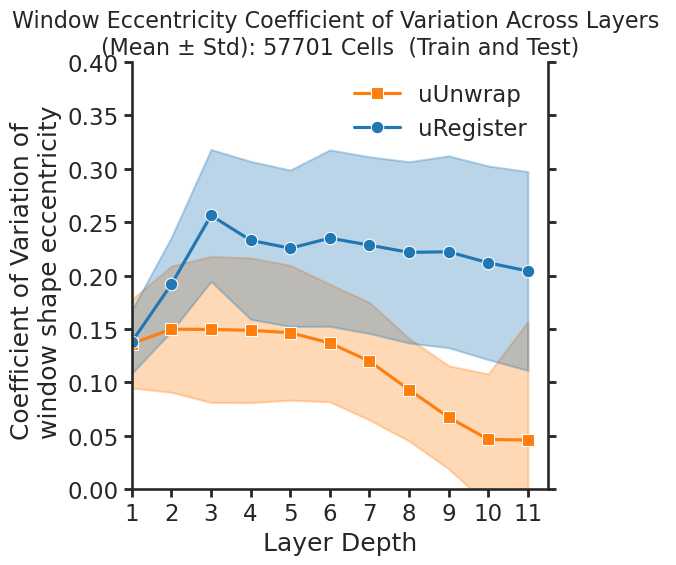

In [6]:
x = np.arange(1, 12)
plt.figure(figsize=(6,6))


sns.lineplot(x=x, y=coef_mean_uUnwrap[:11], marker='s', label='uUnwrap', color='#ff7f0e')
plt.fill_between(x, coef_mean_uUnwrap[:11] - coef_std_uUnwrap[:11], coef_mean_uUnwrap[:11] + coef_std_uUnwrap[:11], 
                 color='#ff7f0e', alpha=0.3)

sns.lineplot(x=x, y=coef_mean_uRegister[:11], marker='o', label='uRegister', color='#1f77b4')
plt.fill_between(x, coef_mean_uRegister[:11] - coef_std_uRegister[:11], coef_mean_uRegister[:11] + coef_std_uRegister[:11], 
                 color='#1f77b4', alpha=0.3)



plt.xlabel('Layer Depth')
plt.ylabel('Coefficient of Variation of \n window shape eccentricity')
plt.title('Window Eccentricity Coefficient of Variation Across Layers \n(Mean ± Std): 57701 Cells  (Train and Test)', fontsize=16)
plt.xlim(1, 11.5)
plt.ylim(0, 0.4)
plt.xticks(x)

ax = plt.gca()


ax.spines['left'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['top'].set_visible(False)

ax.tick_params(axis='x', direction='out', length=6, width=2, bottom=True, top=False)
ax.tick_params(axis='y', direction='out', length=6, width=2, left=True, right=True)


ax.grid(False)


plt.legend(frameon=False)
plt.tight_layout()

plt.savefig("/archive/bioinformatics/Danuser_lab/shared/Yu_Felix_Roshan/1_Paper_All_Reproducibility_Files/Figure_1/Cellpose_benchmark/eccentricity_uregister_vs_uunwrap_remove12.svg", dpi=600, bbox_inches='tight')
plt.show()

# Plot Completeness

In [7]:
fixed_all_comp = [
    np.pad(lst[:12], (0, max(0, 12 - len(lst))), constant_values=np.nan)
    for lst in completeness_results
]
all_comp_uregister = np.array(fixed_all_comp)
uRegister_mean = np.nanmean(all_comp_uregister,axis=0)
uRegister_std = np.nanstd(all_comp_uregister, axis=0)

all_comp_unwrap = [
    [results['completeness'].get(k, np.nan) for k in range(12)]
    for results in (train_unwrap_results + test_unwrap_results)
]

uUnwrap_mean = np.nanmean(all_comp_unwrap, axis=0)
uUnwrap_std = np.nanstd(all_comp_unwrap, axis=0)

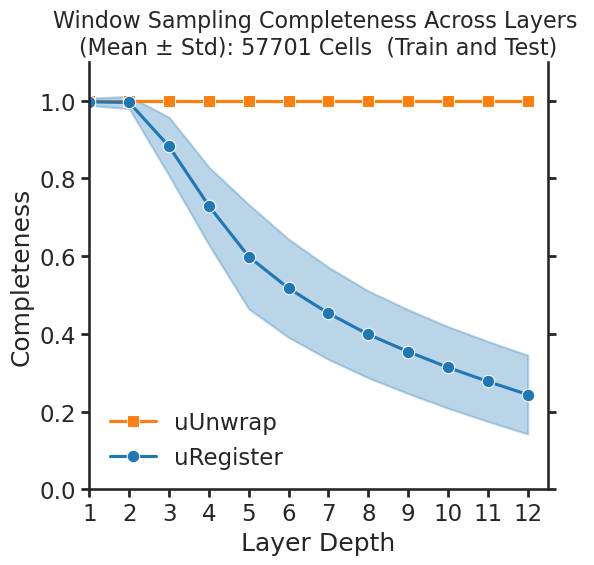

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


x = np.arange(1, 13)



plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans"],
    "axes.linewidth": 2,
})

sns.set(style="white", context="talk")

plt.figure(figsize=(6,6))


sns.lineplot(x=x, y=uUnwrap_mean, marker='s', label='uUnwrap', color='#ff7f0e')
plt.fill_between(x, uUnwrap_mean - uUnwrap_std, uUnwrap_mean + uUnwrap_std, 
                 color='#ff7f0e', alpha=0.3)

sns.lineplot(x=x, y=uRegister_mean, marker='o', label='uRegister', color='#1f77b4')
plt.fill_between(x, uRegister_mean - uRegister_std, uRegister_mean + uRegister_std, 
                 color='#1f77b4', alpha=0.3)

plt.xlabel('Layer Depth')
plt.ylabel('Completeness')
plt.title('Window Sampling Completeness Across Layers \n(Mean ± Std): 57701 Cells  (Train and Test)', fontsize=16)
plt.xlim(1, 12.5)
plt.ylim(0, 1.1)
plt.xticks(x)

ax = plt.gca()


ax.spines['left'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['top'].set_visible(False)

ax.tick_params(axis='x', direction='out', length=6, width=2, bottom=True, top=False)
ax.tick_params(axis='y', direction='out', length=6, width=2, left=True, right=True)


ax.grid(False)


plt.legend(frameon=False)
plt.tight_layout()

plt.savefig("/archive/bioinformatics/Danuser_lab/shared/Yu_Felix_Roshan/1_Paper_All_Reproducibility_Files/Figure_1/Cellpose_benchmark/uUnwrap_vs_uRegister_completeness.svg", dpi=600, bbox_inches='tight')
plt.show()

# Plot area

In [9]:
all_area_unwrap = []

for results in (train_unwrap_results + test_unwrap_results):
    area_lw = results["area_lw"] 
    mean = []

    for k in range(12):
        if k < len(area_lw) and np.max(area_lw[k]) > 0:
            mean.append(np.nanmean(area_lw[k]))
        else:
            mean.append(np.nan)

    all_area_unwrap.append(mean)


In [10]:
fixed_all_area = [
    [
        np.nanmean(layer) if len(layer) > 0 and np.max(layer) > 0 else np.nan
        for layer in lst[:12]
    ] + [np.nan] * max(0, 12 - len(lst))
    for lst in area_results
]

all_area_uregister = np.asarray(fixed_all_area)
uRegister_mean = np.nanmean(all_area_uregister, axis=0)
uRegister_std = np.nanstd(all_area_uregister, axis=0)

all_area_uregister = np.array(fixed_all_area)
uRegister_mean = np.nanmean(all_area_uregister,axis=0)
uRegister_std = np.nanstd(all_area_uregister, axis=0)
all_area_unwrap = np.asarray(all_area_unwrap)

uUnwrap_mean = np.nanmean(all_area_unwrap, axis=0)
uUnwrap_std  = np.nanstd(all_area_unwrap, axis=0)

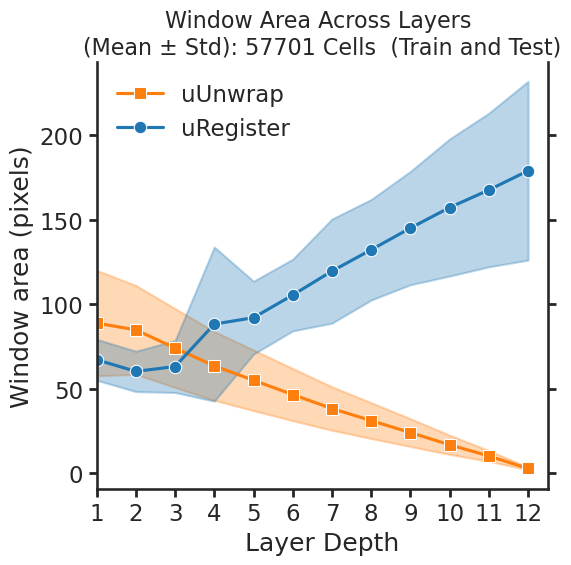

In [11]:
uRegister_std = np.nanstd(all_area_uregister, axis=0)
x = np.arange(1, 13)


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans"],
    "axes.linewidth": 2,
})

sns.set(style="white", context="talk")

plt.figure(figsize=(6,6))


sns.lineplot(x=x, y=uUnwrap_mean, marker='s', label='uUnwrap', color='#ff7f0e')
plt.fill_between(x, uUnwrap_mean - uUnwrap_std, uUnwrap_mean + uUnwrap_std, 
                 color='#ff7f0e', alpha=0.3)

sns.lineplot(x=x, y=uRegister_mean, marker='o', label='uRegister', color='#1f77b4')
plt.fill_between(x, uRegister_mean - uRegister_std, uRegister_mean + uRegister_std, 
                 color='#1f77b4', alpha=0.3)


plt.xlabel('Layer Depth')
plt.ylabel('Window area (pixels)')
plt.title('Window Area Across Layers \n(Mean ± Std): 57701 Cells  (Train and Test)', fontsize=16)
plt.xlim(1, 12.5)

plt.xticks(x)

ax = plt.gca()


ax.spines['left'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['top'].set_visible(False)

ax.tick_params(axis='x', direction='out', length=6, width=2, bottom=True, top=False)
ax.tick_params(axis='y', direction='out', length=6, width=2, left=True, right=True)


ax.grid(False)


plt.legend(frameon=False)
plt.tight_layout()

plt.savefig("/archive/bioinformatics/Danuser_lab/shared/Yu_Felix_Roshan/1_Paper_All_Reproducibility_Files/Figure_1/Cellpose_benchmark/area_uregister_vs_uunwrap.svg", dpi=600, bbox_inches='tight')
plt.show()